# 08 — Results synthesis

Collect outputs from the empirical, simulation, and stress notebooks. Do not interpret demo-price results as empirical findings.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
CACHE = ROOT / 'results/notebook_cache'

In [2]:
evaluation = pd.read_csv(CACHE / 'combined_evaluation.csv')
portfolio = pd.read_csv(CACHE / 'portfolio_evaluation.csv')
simulation = pd.read_csv(CACHE / 'simulation_results.csv')
scale = pd.read_csv(CACHE / 'scale_stress.csv')
tail = pd.read_csv(CACHE / 'tail_stress.csv')
display(evaluation.sort_values('energy_score'))
display(portfolio)

,dgp,forecast_model,innovation_model,avg_coverage,avg_width,energy_score,crps,interval_score,ece,pit_deviation,...,width_1,coverage_2,width_2,coverage_3,width_3,coverage_4,width_4,nominal_coverage,coverage_error,abs_coverage_error
0,financial,VAR,gaussian,0.894628,0.037039,0.014032,0.006034,0.046202,0.014738,0.011157,...,0.025745,0.851240,0.033599,0.867769,0.035197,0.966942,0.053614,0.9,-0.005372,0.005372
2,financial,VAR,bootstrap,0.888430,0.036546,0.014072,0.006049,0.046443,0.023967,0.011405,...,0.024257,0.867769,0.033843,0.859504,0.036013,0.975207,0.052071,0.9,-0.011570,0.011570
1,financial,VAR,student_t,0.869835,0.035086,0.014126,0.006068,0.046231,0.043251,0.010496,...,0.024370,0.859504,0.032364,0.809917,0.033313,0.966942,0.050297,0.9,-0.030165,0.030165
3,financial,VAR,diffusion,0.944215,0.044211,0.014490,0.006182,0.048554,0.074518,0.021736,...,0.030279,0.933884,0.040678,0.933884,0.042172,0.991736,0.063714,0.9,0.044215,0.044215


,innovation_model,portfolio_95_var_exceedance,mean_portfolio_q05
0,gaussian,0.049587,-0.013195
1,student_t,0.049587,-0.012521
2,bootstrap,0.057851,-0.012364
3,diffusion,0.057851,-0.012159


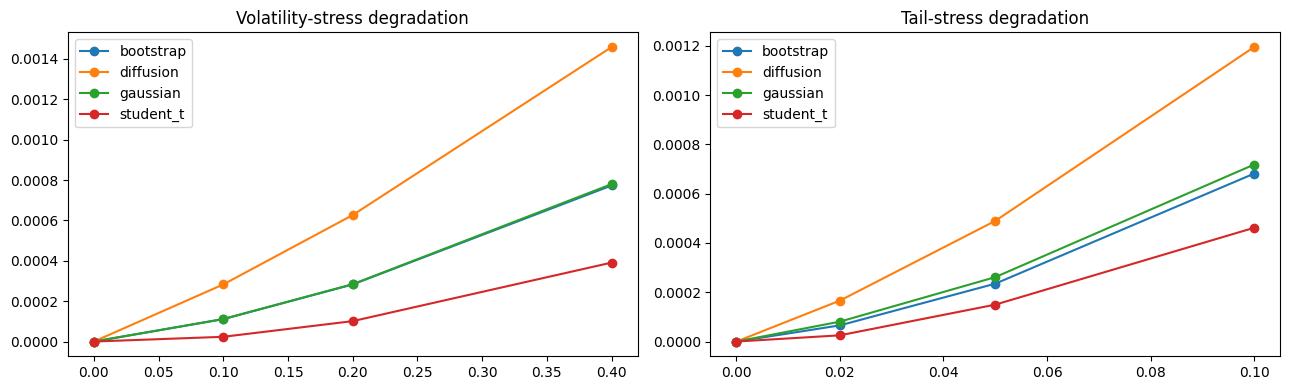

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, group in scale.groupby('innovation_model'):
    axes[0].plot(group['epsilon_value'], group['energy_score_degradation'], marker='o', label=name)
for name, group in tail.groupby('innovation_model'):
    axes[1].plot(group['contamination_prob'], group['energy_score_degradation'], marker='o', label=name)
axes[0].set_title('Volatility-stress degradation')
axes[1].set_title('Tail-stress degradation')
axes[0].legend()
axes[1].legend()
plt.tight_layout();

## Interpretation checklist

- Was the input real market data or the demo fallback?
- Did a model improve calibration without becoming uninformatively wide?
- Are conclusions consistent across marginal, joint, tail, and portfolio metrics?
- Does DI-VAR materially outperform simpler baselines relative to its compute cost?
- Which distributional shift causes each model to fail first?
- Are results stable across forecast origins, time windows, and random seeds?